In [1]:
using QuantumOptics

In [2]:
using Plots

In [3]:
b = FockBasis(10)
alpha = 2.0 + 0.0im
state = coherentstate(b, alpha)

Ket(dim=11)
  basis: Fock(cutoff=10)
  0.1353352832366127 + 0.0im
  0.2706705664732254 + 0.0im
 0.38278598604164366 + 0.0im
  0.4420031841663186 + 0.0im
  0.4420031841663186 + 0.0im
  0.3953396664268989 + 0.0im
  0.3227934859426707 + 0.0im
 0.24400893961026585 + 0.0im
 0.17254037586855772 + 0.0im
 0.11502691724570514 + 0.0im
 0.07274941014482605 + 0.0im

In [4]:
xvec = LinRange(-5, 5, 100)
pvec = LinRange(-5, 5, 100)

100-element LinRange{Float64, Int64}:
 -5.0, -4.89899, -4.79798, -4.69697, …, 4.69697, 4.79798, 4.89899, 5.0

In [89]:
W = wigner(state, xvec, pvec)

# 4. Plot using Plots.jl
contourf(xvec, pvec, W, 50,
    title="Wigner Function",
    xlabel="Position x",
    ylabel="Momentum p",
    aspect_ratio=:equal,
    colorbar=true
)

UndefVarError: UndefVarError: `contourf` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in Plots.
Hint: a global variable of this name also exists in GR.
Hint: a global variable of this name also exists in PyPlot.

In [6]:
b1 = FockBasis(10)
alpha1 = 2.0 + 0.0im
state1 = fockstate(b1, 5)

Ket(dim=11)
  basis: Fock(cutoff=10)
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

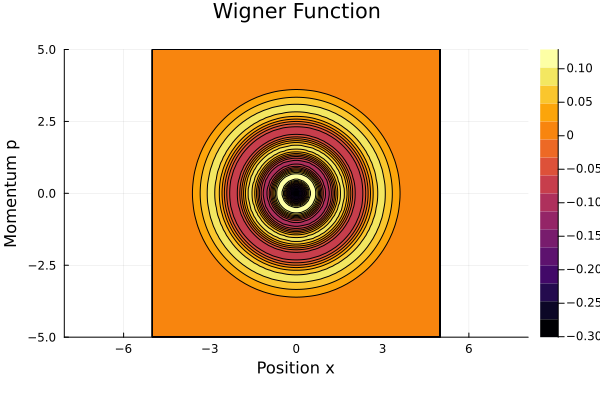

In [7]:
W = wigner(state1, xvec, pvec)

# 4. Plot using Plots.jl
contourf(xvec, pvec, W, 
    title="Wigner Function",
    xlabel="Position x",
    ylabel="Momentum p",
    aspect_ratio=:equal,
    colorbar=true
)

In [86]:
using IonSim
using QuantumOptics

# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
ϵ_vec = (x̂ + ŷ) / √2

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13

# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(ion["g"] + ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:100.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase C:\Users\jewoo\.julia\packages\SciMLBase\pzpcE\src\integrator_interface.jl:626


81×81 Matrix{Float64}:
 4.03776e-15  8.89675e-15  1.92148e-14  …  8.89363e-15  4.03631e-15
 8.89645e-15  1.96023e-14  4.23362e-14     1.95954e-14  8.89325e-15
 1.92135e-14  4.23347e-14  9.14327e-14     4.23199e-14  1.92066e-14
 4.06734e-14  8.96191e-14  1.93555e-13     8.95877e-14  4.06588e-14
 8.43973e-14  1.8596e-13   4.01627e-13     1.85895e-13  8.43669e-14
 1.71657e-13  3.78226e-13  8.16875e-13  …  3.78093e-13  1.71595e-13
 3.42221e-13  7.54045e-13  1.62855e-12     7.5378e-13   3.42098e-13
 6.68755e-13  1.47352e-12  3.18245e-12     1.47301e-12  6.68515e-13
 1.28098e-12  2.82249e-12  6.09588e-12     2.8215e-12   1.28052e-12
 2.40508e-12  5.29932e-12  1.14452e-11     5.29747e-12  2.40422e-12
 ⋮                                      ⋱               ⋮
 1.27773e-12  2.81533e-12  6.08041e-12     2.81434e-12  1.27727e-12
 6.67005e-13  1.46967e-12  3.17413e-12     1.46916e-12  6.66766e-13
 3.41299e-13  7.52012e-13  1.62416e-12     7.51749e-13  3.41176e-13
 1.7118e-13   3.77176e-13  8.14608e

In [30]:
import Pkg
Pkg.add("PyPlot")
using PyPlot

   Resolving package versions...
   Installed Xorg_libpciaccess_jll ─ v0.18.1+0
   Installed libdrm_jll ──────────── v2.4.125+1
   Installed libva_jll ───────────── v2.23.0+0
    Updating `C:\Users\jewoo\projects\TestJulia\Project.toml`
  [d330b81b] + PyPlot v2.11.6
    Updating `C:\Users\jewoo\projects\TestJulia\Manifest.toml`
  [a65dc6b1] + Xorg_libpciaccess_jll v0.18.1+0
  [8e53e030] + libdrm_jll v2.4.125+1
  [9a156e7d] + libva_jll v2.23.0+0
Precompiling packages...
    980.1 ms  ✓ Xorg_libpciaccess_jll
    490.2 ms  ✓ libdrm_jll
    486.5 ms  ✓ libva_jll
  3 dependencies successfully precompiled in 4 seconds. 457 already precompiled.


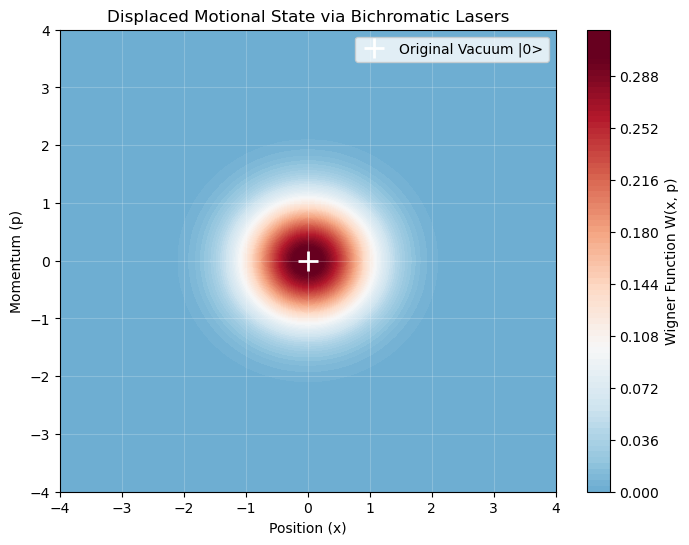

In [88]:
fig = figure(figsize=(8, 6))
PyPlot.contourf(x_vec, p_vec, W, 100, cmap="RdBu_r", vmin=-0.1, vmax=0.3)
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [46]:
using Printf
function print_pulse_schedule(chamber; t_start=0.0, t_end=30.0, step=0.1)
        L = chamber.lasers[1]
        I_func = L.I
        phi_func = L.ϕ
        
        println("\n--- Laser Pulse Schedule ---")
        println("Time (μs) | Intensity (W/m²)     | Phase (rad)")
        println("----------------------------------------------")
        
        # We assume 't' is in microseconds because hamiltonian(timescale=1e-6) is used
        for t in t_start:step:t_end
            i_val = I_func(t)
            p_val = phi_func(t)
            
            # Only print lines where the laser is ON to keep output clean
            if i_val > 1e-9
                # Format: Time aligned right, Intensity scientific, Phase fixed
                Printf = @eval using Printf
                @Printf.printf "%9.2f | %18.2e | %5.2f\n" t i_val p_val
            end
        end
        println("----------------------------------------------\n")
    end

print_pulse_schedule (generic function with 1 method)

In [47]:
print_pulse_schedule(trap)


--- Laser Pulse Schedule ---
Time (μs) | Intensity (W/m²)     | Phase (rad)
----------------------------------------------
     0.00 |           2.00e+07 |  0.00
     0.10 |           2.00e+07 |  0.00
     0.20 |           2.00e+07 |  0.00
     0.30 |           2.00e+07 |  0.00
     0.40 |           2.00e+07 |  0.00
     0.50 |           2.00e+07 |  0.00
     0.60 |           2.00e+07 |  0.00
     0.70 |           2.00e+07 |  0.00
     0.80 |           2.00e+07 |  0.00
     0.90 |           2.00e+07 |  0.00
     1.00 |           2.00e+07 |  0.00
     1.10 |           2.00e+07 |  0.00
     1.20 |           2.00e+07 |  0.00
     1.30 |           2.00e+07 |  0.00
     1.40 |           2.00e+07 |  0.00
     1.50 |           2.00e+07 |  0.00
     1.60 |           2.00e+07 |  0.00
     1.70 |           2.00e+07 |  0.00
     1.80 |           2.00e+07 |  0.00
     1.90 |           2.00e+07 |  0.00
     2.00 |           2.00e+07 |  0.00
     2.10 |           2.00e+07 |  0.00
     2.20 |       

In [85]:
# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
k_vec = (x̂ + ẑ) / √2
ϵ_vec = (x̂ - ẑ) / √2

laser_intensity = 5e5 
transition_λ = 729e-9 
B_field = 1e-13 # Our magnetic field

# CALCULATE THE EXACT ZEEMAN OFFSET
# Shift = Shift(excited) - Shift(ground)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Chamber
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

Zeeman Offset: 0.0005611952854826817 Hz


Chamber

In [71]:
# 2. Check the coupling strength (Carrier Rabi frequency)
# We test just the red laser acting on the carrier transition
carrier_matrix_element = IonSim.matrix_element(ion, ("g", "e"), 1.0, L_red.k, L_red.ϵ, trap.Bhat)

# The Rabi frequency (in Hz) is proportional to the electric field (√Intensity)
# IonSim handles the exact atomic dipole constants internally.
E_field = sqrt(2 * L_red.I / (IonSim.c * IonSim.ε₀))
raw_rabi_freq = abs(carrier_matrix_element * E_field / IonSim.h)

println("Raw Carrier Rabi Frequency: ", raw_rabi_freq / 1e3, " kHz")

# For a 100 μs displacement to be visible, you want this Carrier Rabi Frequency 
# to be roughly 50 kHz to 200 kHz. If it says 0.1 kHz, the laser is way too weak!

UndefVarError: UndefVarError: `matrix_element` not defined in `IonSim`
Suggestion: check for spelling errors or missing imports.

In [73]:
# 3. Check if the internal state is being destroyed
P_e = ionprojector(trap, "e")
excited_pop = real.(expect(P_e, sol))

fig2 = figure(figsize=(8, 4))
PyPlot.plot(tspan, excited_pop, linewidth=2, color="purple")
ylim(0, 1)
xlabel("Time (μs)")
ylabel("Population of |e>")
title("Internal State Integrity (Should remain flat at 0.5)")
grid(true, linestyle="--")
display(fig2)

PyCall.PyError: PyError ($(Expr(:escape, :(ccall(#= C:\Users\jewoo\.julia\packages\PyCall\1gn3u\src\pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'ValueError'>
ValueError('x and y must have same first dimension, but have shapes (201,) and (77,)')
  File "C:\Users\jewoo\.julia\conda\3\x86_64\Lib\site-packages\matplotlib\pyplot.py", line 3838, in plot
    return gca().plot(
           ^^^^^^^^^^^
  File "C:\Users\jewoo\.julia\conda\3\x86_64\Lib\site-packages\matplotlib\axes\_axes.py", line 1777, in plot
    lines = [*self._get_lines(self, *args, data=data, **kwargs)]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jewoo\.julia\conda\3\x86_64\Lib\site-packages\matplotlib\axes\_base.py", line 297, in __call__
    yield from self._plot_args(
               ^^^^^^^^^^^^^^^^
  File "C:\Users\jewoo\.julia\conda\3\x86_64\Lib\site-packages\matplotlib\axes\_base.py", line 494, in _plot_args
    raise ValueErr